# Neural Computing Assignment

This assignment will introduce you to train various neural network architectures on the EMNIST dataset to classify numbers and letters. You will also perform a hyperparameter optimization study and analyse which part of the models are responsible for various tasks. You have to implement the code and **explain and analyse it in the markdown cells below**. You should hand in:
- the finished jupyter notebook with executed cells so that we can check the outputs
- all the trained and saved models whose performance is shown in the completed notebook 

---
## Grading Criteria

### Overview

- **General Quality:** 50%  
- **Part-Specific Evaluation:** 50%

---

### 1. General Quality (50%)

- **Code Implementation (20%)**  
  Correctness, structure, and readability of the implementation.

- **Plot Quality & Analysis (20%)**  
  Clarity of visualizations and ability to extract meaningful insights.

- **Scientific Standards (10%)**  
  Proper use of data splits and sound experimental methodology.

---

### 2. Part-Specific Evaluation (50%)

- **Part 1 (10%)**  
  Correct implementation of the baseline pipeline (model, training, evaluation) and ability to reproduce expected behavior.

- **Part 2 (15%)**  
  Development and comparison of multiple models, with clear analysis of differences in performance and behavior.

- **Part 3 (15%)**  
  Improvement over baseline through informed design choices (e.g., architecture, hyperparameters), supported by evidence.

- **Part 4 (10%)**  
  Ability to generalize methods to new settings and provide clear reasoning for design decisions.

---

## Notes for Students

- Emphasis is placed on **clarity, correctness, and understanding**, not only prediction performance.  
- Well-structured code and clear explanations are essential for a high grade.  
- Plots and analysis should support your conclusions, not just be included.
---

## Setup

First of all, you will need to install the required packages. You can automatically get all the packages through uv.

If you want to automatically install them, install uv (https://docs.astral.sh/uv/getting-started/installation/)

After uv is installed, run:

`uv init` (This initialises uv in your repository and creates the virtual environment)

`uv sync` (This automatically matches your installed packages with those in pyproject.toml)

If your computer supports a cuda version other than 13.0 or does not support cuda, you may need to modify pyproject.toml. 

You are also free to install the packages any other way.

Additional remarks

- The imports below are just an example, you are free to import more libraries.
- We give some basic functions to fill up. You should use these functions and not change their names, as we will grade based on them. However, you are free (and encouraged) to add more arguments to them and add helper functions.
- If your computer supports CUDA, make sure you have PyTorch installed with CUDA, as it will significanly reduce computation time. Macs do not have CUDA, but you may be able to use mps.
- Make sure your results are reproducible and run in a reasonable time. This assignment should not require you to run a single cell for hours.

In [1]:
%%time 

import torch
from torch import Tensor
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import torch.optim as optim
from scipy.signal import savgol_filter
import numpy as np
import os
from addict import Dict
import optuna
import gc

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device {device}")

Using device mps
CPU times: user 999 ms, sys: 183 ms, total: 1.18 s
Wall time: 1.32 s


In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [3]:
# fix all seeds
torch.manual_seed(69)
# everywhere 
import random 
random.seed(69) 
np.random.seed(69) 
torch.cuda.manual_seed(69) 
torch.cuda.manual_seed_all(69)

## Part 1: Create a simple fully connected network

This part is a introduction how to train neural networks. You will load and investigate the **balanced** EMNIST dataset and write a training and evaluation function. For this part, we will train a simple fully connected network using the pytorch library. 

Explain below, how the balanced EMNIST dataset looks like and how the train and evaluate function works.

First you should load the EMNIST dataset, prepare it and set up the dataloader for later training. 

In [4]:
%%time 

import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

use_subset = True

# (Assuming they want us to used 'balanced' as the split since they say "download the balanced emnist')
EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=True, transform=ToTensor())
label_names = EMNIST_dataset.classes

# subset of the dataset for when testing to not have to wait a long time
EMNIST_subset = Subset(EMNIST_dataset, indices=range(100))

#batch size of 10 since thats what they ask us to show in the picture

if use_subset:
    EMNIST_dataloader = DataLoader(EMNIST_subset, batch_size=10, shuffle=True)
else:
    EMNIST_dataloader = DataLoader(EMNIST_dataset, batch_size=10, shuffle=True)

CPU times: user 3.1 ms, sys: 10.2 ms, total: 13.3 ms
Wall time: 12.7 ms


Write code to show a overview of 10 EMNIST examples. The image shows how we plotted the EMNIST overview. Make sure that your code produces the same or very similar images as shown below (it does not have to show the exact same characters, but it needs to show some characters in the same format). You may need to do some transformations to your data.

![image.png](multiple_images_emnist.png)

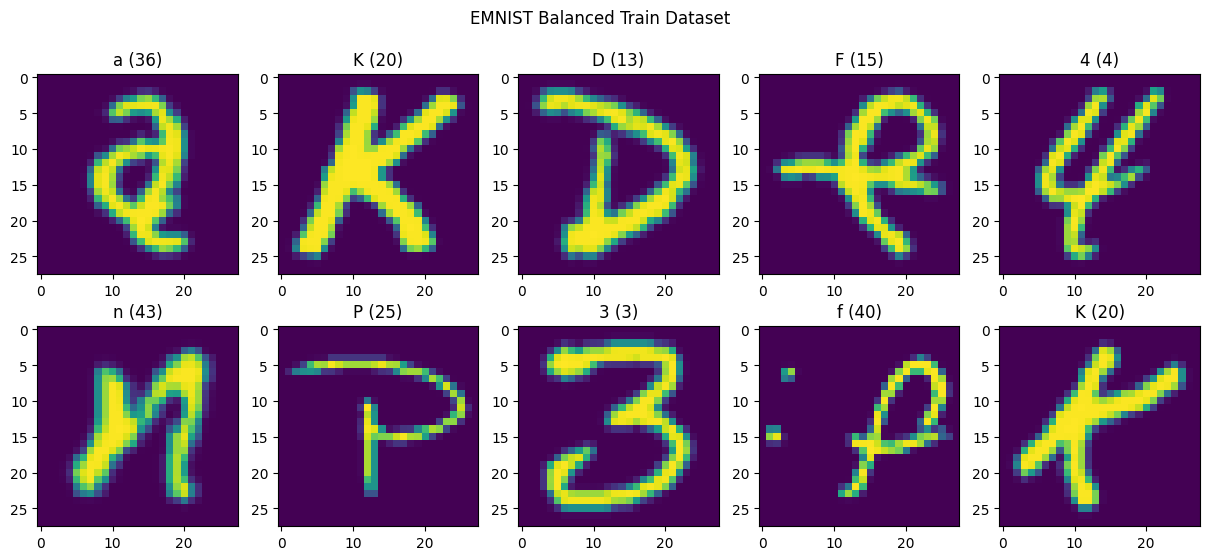

In [5]:
def show_multiple_images(data):
    
    #get first sample
    train_feat, train_lab = next(iter(EMNIST_dataloader))
    label_names = EMNIST_dataset.classes
    
    # so images are 1x28x28 and we have 10 -> a sample is a tensor of 10x1x28x28
    train_feat.size()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # flatten axes so that we can iterate through them linearly
    axes = axes.flatten()
    
    for img_idx in range(len(train_feat)):
        image = train_feat[img_idx]
        img_subplot = axes[img_idx]
    
        # remove the first unneeded dimension
        image = image.reshape((28, 28))
    
        # Transposing the image, so that it matches the orientation of the EMNIST images 
        img_subplot.imshow(image.T.numpy())
        img_subplot.set_title(f'{label_names[train_lab[img_idx]]} ({train_lab[img_idx]})')

    fig.suptitle("EMNIST Balanced Train Dataset")

show_multiple_images(EMNIST_dataloader)

Create a simple fully connected network.

In [6]:
# assuming that fully connected has only 1 hidden layer since they specify only 1 hidden size

class SimpleFCNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes) -> None:

        super().__init__()

        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, num_classes)

        
    def forward(self, x):
        x = x.flatten(start_dim=1)

        # feedforward & then softmax
        x = F.relu(self.layer1(x))

        # im guessing we always pass batches through
        # CrossEntropyLoss (used later) expects logits already does LogSoftmax 
        # x = F.softmax(self.layer2(x), dim=1)

        x = self.layer2(x)
        return x

    # for checkpointing already trained models, since it takes a long time to run otherwise
    def save(self, path='saved_model_checkpoints/'):
        os.makedirs(path, exist_ok=True)
        
        checkpoint = {
            'model_state_dict': self.state_dict(),
            'architecture': {
                'input_size': self.layer1.in_features,
                'hidden_size': self.layer1.out_features,
                'num_classes': self.layer2.out_features
            }
        }
        filepath = os.path.join(path, 'feedforward-model.pth')
        torch.save(checkpoint, filepath)
        print(f"Model checkpoint saved to {filepath}")  

In [7]:
def evaluate(model, loader, with_print=False) -> None:
    """Method to evaluate the model on the test dataset.

    Args:
        model (nn.Module): the trained neural network model
        loader (torch.utils.data.DataLoader): the balanced EMNIST test dataset

    Returns:
        float: The accuracy

    """
    
    correct = 0
    model.eval()
    total = len(loader.dataset)

    # we dont need gradients for eval
    with torch.no_grad():
        if with_print:
            print('')
        for idx, (images, labels) in enumerate(loader):

            images = images.to(device) 
            labels = labels.to(device) 

            if with_print:
                print(f'\rEvaluation on epoch: {idx}/{len(loader)}', end='', flush=True)
            
            outputs = model.forward(images) # 10x47 (score for each label)
            predicted_labels = torch.argmax(outputs, dim=1) # 10 number label prediction
            correct += (predicted_labels == labels).sum().item()

    if with_print:
        print('')
        
    accuracy = correct / total
    return accuracy


def train_one_epoch(model, train_loader, optimizer, loss_fn, with_print=False):
    """Performs a single training epoch over the entire dataset.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data (images and labels).
        optimizer (torch.optim.Optimizer): The optimization algorithm used
            to update model parameters.
        loss_fn (nn.modules.loss._Loss): The loss function used to calculate
            the error.

    Returns:
        float: The cumulative loss for the entire epoch, calculated as the
            sum of losses from each individual batch.
    """

    # inform torch that we're training 
    model.train() 

    cumulative_loss = 0.0

    # for each batch
    for idx, (images, labels) in enumerate(train_loader):
        
        # Enables CUDA if available  
        images = images.to(device) 
        labels = labels.to(device) 
        optimizer.zero_grad()

        # pass batch through network
        outputs = model(images)

        # get loss
        loss = loss_fn(outputs, labels)

        # backprop
        loss.backward()

        # update
        optimizer.step()

        cumulative_loss += loss.item()
        
        print(f'\rbatch {idx}/{len(train_loader)} loss: ' + str(loss.item()), end='')
    print('')

    return cumulative_loss


def train_num_epochs(model, train_loader, optimizer, loss_fn, num_epochs, with_checkpointing=False, scheduler=None):
    """Training over multiple epochs. 
    This function repeatedly calls the `train_one_epoch` function, calculates the average loss per batch for each epoch, 
    and prints a progress report to the console. 
    This function shouldn't keep track of the training accuracy and is therefore more efficient than the train_with_accuracyplotting method.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data.
        optimizer (torch.optim.Optimizer): The optimization algorithm (e.g., Adam or SGD).
        loss_fn (nn.modules.loss._Loss): The loss function used to evaluate model performance.
        num_epochs (int): The total number of full passes over the training dataset.
    """

    best_avg_batch_loss = float('inf')
    
    for epoch in range(num_epochs):
       # to calculate avg loss per batch for an epoch its cum_loss/num_batches
        epoch_cum_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

        avg_batch_loss = epoch_cum_loss / len(train_loader)

        print(f'Epoch: {epoch} | avg batch loss: {avg_batch_loss}')

        if with_checkpointing and avg_batch_loss < best_avg_batch_loss:
            print('checkpointing model')
        
        if scheduler is not None: 
            scheduler.step()


def train_num_epochs_and_track_accuracies(
    model, train_loader, test_loader, optimizer, loss_fn, num_epochs, initial_best_acc=0.0, with_checkpointing = False, scheduler = None
):
    """Trains the model and tracks accuracy for both training and test sets.

    This function performs a full training cycle for a specified number of epochs. 
    After each training pass, it evaluates the model's performance on both the training and test datasets to monitor for convergence and overfitting.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing training data batches.
        test_loader (torch.utils.data.DataLoader): The DataLoader providing  validation/test data batches.
        optimizer (torch.optim.Optimizer): The optimization algorithm.
        loss_fn (nn.modules.loss._Loss): The loss function used for training.
        num_epochs (int): Total number of times to iterate over the dataset.

    Returns:
        tuple: A tuple containing the trained model and the accuracies
    """

    train_accuracies = []
    test_accuracies = []

    best_test_acc = initial_best_acc 

    # get first accuracy
    print("evaluating model")
    train_acc = evaluate(model, train_loader, with_print=False)
    test_acc = evaluate(model, test_loader, with_print=False)
    print(f"Train acc: {train_acc} | Test acc: {test_acc}")

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

   
    for epoch in range(num_epochs):
        
        # to calculate avg loss per batch for an epoch its cum_loss/num_batches
        epoch_cum_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    
        avg_batch_loss = epoch_cum_loss / len(train_loader)
    
        print(f'Epoch: {epoch} | avg batch loss: {avg_batch_loss}')

        # get accuracy 
        print("evaluating model")
        train_acc = evaluate(model, train_loader, with_print=False)
        test_acc = evaluate(model, test_loader, with_print=False)
        print(f"Train acc: {train_acc} | Test acc: {test_acc}")

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)


        if with_checkpointing and test_acc > best_test_acc:
            best_test_acc = test_acc
            model.save()
            print(f"checkpointing model - test accuracy: {best_test_acc:.4f}")

        if scheduler is not None:
            scheduler.step()

    return model, train_accuracies, test_accuracies


In [8]:
def accuracy_curve(model_name, accuracies):
    """
    Creates a line plot of the model's accuracy over the epochs. Compares the train and test accuracy of the various models
    Args:
        model_name: Str
            Name for file naming
        accuracies: List
            List of lists
            Each list is one epoch and contains train-, test- and verification accuracy
    """
    
    train_accs = [epoch[0] for epoch in accuracies]
    test_accs  = [epoch[1] for epoch in accuracies]
    epochs     = range(1, len(accuracies) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
    plt.plot(epochs, test_accs,  label='Test Accuracy',  linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy over Epochs — {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

No checkpoint found, starting from scratch.
Initializing model from scratch
evaluating model
Train acc: 0.02220744680851064 | Test acc: 0.02171985815602837
batch 9023/9024 loss: 0.86533182859420785
Epoch: 0 | avg batch loss: 1.1514268181066307
evaluating model
Train acc: 0.7391843971631206 | Test acc: 0.7287234042553191
Model checkpoint saved to saved_model_checkpoints/feedforward-model.pth
checkpointing model - test accuracy: 0.7287
batch 9023/9024 loss: 1.467234253883361856
Epoch: 1 | avg batch loss: 0.7598251112190187
evaluating model
Train acc: 0.7885749113475178 | Test acc: 0.7674202127659574
Model checkpoint saved to saved_model_checkpoints/feedforward-model.pth
checkpointing model - test accuracy: 0.7674
batch 9023/9024 loss: 1.607713937759399444
Epoch: 2 | avg batch loss: 0.6280173390683906
evaluating model
Train acc: 0.8121010638297872 | Test acc: 0.7865248226950354
Model checkpoint saved to saved_model_checkpoints/feedforward-model.pth
checkpointing model - test accuracy: 0.7

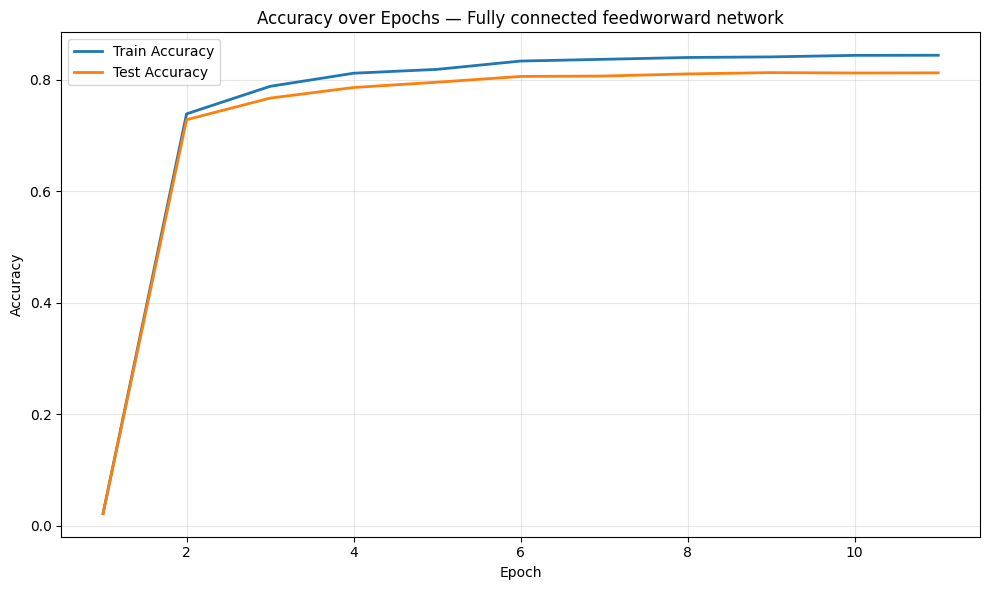

CPU times: user 1min 36s, sys: 33.2 s, total: 2min 9s
Wall time: 3min 37s


In [9]:
%%time 

from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

# load data
EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=False, transform=ToTensor())

#batch size of 10 since thats what they ask us to show in the picture
EMNIST_dataloader = DataLoader(EMNIST_dataset, batch_size=10, shuffle=True)

# define the train & test size splits
train_test_split = 0.8

train_size = int(train_test_split * len(EMNIST_dataset))
test_size = len(EMNIST_dataset) - train_size

train_dataset, test_dataset = random_split(EMNIST_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=10, shuffle=False)

# Query best accuracy so far
load_accuracy = True 
initial_best_acc = 0.0 
model = None 
if load_accuracy: 
    try: 
        # Model params 
        checkpoint = torch.load('saved_model_checkpoints/feedforward-model.pth')
        arch = checkpoint['architecture']
        model = SimpleFCNetwork(arch['input_size'], arch['hidden_size'], arch['num_classes']).to(device) 
        model.load_state_dict(checkpoint['model_state_dict']) 
        print("Loaded model from checkpoint.") 
        # Starting accuracy baseline 
        print("Evaluating loaded model to get initial accuracy...") 
        initial_best_acc = evaluate(model, test_loader) 
        print(f"Initial best test accuracy set to: {initial_best_acc:.4f}") 
    except FileNotFoundError: 
        print("No checkpoint found, starting from scratch.")
# load model
load_checkpoint = True
if load_checkpoint and not (model is None):
    print("Using loaded model") 
    pass 
else:
    print("Initializing model from scratch") 
    model = SimpleFCNetwork(28*28, 64, len(label_names)).to(device)

#optimizer = optim.SGD(model.parameters(), lr=0.01)
optimizer = optim.Adam(model.parameters(), lr=0.001) 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5) 
loss = nn.CrossEntropyLoss()

model, train_accs, test_accs = train_num_epochs_and_track_accuracies(model=model, 
                                                                     train_loader=train_loader, 
                                                                     test_loader=test_loader, 
                                                                     optimizer=optimizer, 
                                                                     loss_fn=loss, 
                                                                     num_epochs=10,
                                                                     initial_best_acc=initial_best_acc,
                                                                     with_checkpointing=True,
                                                                     scheduler=scheduler)

#print("prev acc: " + str(prev_acc))
#print("new acc: " + str(evaluate(model, EMNIST_dataloader)))

accuracy_curve("Fully connected feedworward network", list(zip(train_accs, test_accs)))

### 🖊️📜 (200 words max)

Explain here:
- How the EMNIST dataset looks like.
- The structure of the network.

# Part 2: Implement and compare additional Neural Network architectures
In this task you will have to research four different neural network architectures and implement them in this notebook. Explain the structure of those architectures below! Train those model architectures on the EMNIST dataset and compare their accuracies below. Think of a smart way to compare the networks visually in a plot, such as taught in one of the lectures. Also pay attention on which models might be overfitting.

In [10]:
class CNN_SMALL(nn.Module):
    def __init__(self, num_classes=47):
        """
        Basic convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100

        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  # -> 32x28x28
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # -> 64x14x14
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)                                 # halves spatial dims

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x: torch.Tensor
                The input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        # handle both (N, 28, 28) and (N, 1, 28, 28) inputs
        if x.dim() == 3:
            x = x.unsqueeze(1)           # -> (N, 1, 28, 28)

        x = self.pool(F.relu(self.conv1(x)))  # -> (N, 32, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))  # -> (N, 64,  7,  7)

        # flatten everything
        x = x.view(x.size(0), -1)            # -> (N, 64*7*7)

        x = F.relu(self.fc1(x))              # -> (N, 256)
        x = self.fc2(x)                      # -> (N, num_classes)

        return x

In [11]:
class CNN_BIG(nn.Module):
    def __init__(self, num_classes=47):
        """
        Advanced convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100
        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()
        
        # 1x28x28 -> 32x28x28 -> 32x14x14
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # normalize outputs

        # 32x14x14 -> 64x14x14 -> 64x7x7
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) # normalize outputs

        # 64x7x7 -> 128x7x7 -> 128x3x3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) # normalize outputs

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 128 * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        """
        Define the forward pass of the neural network.
        Args:
            x: torch.Tensor
                The input tensor.
        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        
        # handle both (N, 28, 28) and (N, 1, 28, 28) inputs
        if x.dim() == 3:
            x = x.unsqueeze(1)                         # (N, 1,   28, 28)

        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # (N, 32,  14, 14)
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # (N, 64,   7,  7)
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # (N, 128,  3,  3)

        x = x.view(x.size(0), -1)                      # (N, 1152)

        x = F.relu(self.fc1(x))                        # (N, 256)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))                        # (N, 128)
        x = self.fc3(x)                                # (N, num_classes)

        return x

In [12]:
class BasicBlock(nn.Module):
    """Standard residual block used in ResNet architectures."""

    # this is used in the standard torch implementations, keeping it in case its required for any later tests
    expansion = 1 

    def __init__(self, in_channels, out_channels, stride=1):
        """Initializes the BasicBlock.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels for the first convolution.
            stride (int, optional): Stride for the first convolutional layer. Default is 1.
        """
        super().__init__()
        # Basic Block according to ResNet paper (2 layer convolution with batchnorm)
        # Main path F(x), using two convolutions 
        # 1st 3x3 convolution  
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=stride, padding=1, bias=False) 
        self.bn1 = nn.BatchNorm2d(out_channels) 

        # ReLU activation 
        self.ReLU = nn.ReLU() 

        # Main path; 2nd 3x3 convolution
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels = out_channels * self.expansion, kernel_size=3, stride=1, padding=1, bias=False) 
        self.bn2 = nn.BatchNorm2d(out_channels * self.expansion) 

        # Shortcut path (x) 
        if stride != 1 or in_channels != out_channels * self.expansion: 
            # we use 1x1 convolution to match dimensions if the input / output differ 
            self.shortcut = nn.Sequential(nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False), nn.BatchNorm2d(out_channels * self.expansion),)
        else: 
            # Preserve the same x unchanged otherwise
            self.shortcut = nn.Identity() 
        

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor after passing through the network.
        """

        # when we do a shortcut we preserve the input 
        identity = self.shortcut(x) 

        # main branch learns residual correction F(x) 
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out)) 

        # residual connection is output = F(x) + shortcut(x)
        out = out + identity 
        out = F.relu(out) 
        return out 


class ResNet(nn.Module):
    """Generic ResNet architecture implementation.

    This class constructs a Deep Residual Network by stacking multiple layers, where each layer contains a specific number of residual blocks (BasicBlock or
    Bottleneck).
    """

    def __init__(self, block=BasicBlock, num_block=(2,2,2,2), num_classes=47):
        """
        Initializes the ResNet model.

        Args:
            block (nn.Module): The block class to use.
            num_block (list[int]): A list of 4 integers defining the number of blocks
                in each of the four stages
            num_classes (int, optional): Number of output classes.
            name (str, optional): Name of the model. Default is "resnet".
        """
        super().__init__() 

        self.in_channels = 64

        # initial convolution  1x28x28 -> 64x28x28  
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False) 
        self.bn1 = nn.BatchNorm2d(64)

        # four resnet stages
        # 64x28x28 -> 64x28x28, first layer without downsampling 
        self.layer1 = self._make_layer(block, out_channels=64, num_blocks=num_block[0], stride=1) 

        # 64x28x28 -> 128x14x14 
        self.layer2 = self._make_layer(block, out_channels=128, num_blocks=num_block[1], stride=2) 

        # 128x14x14 -> 256x7x7 
        self.layer3 = self._make_layer(block, out_channels=256, num_blocks=num_block[2], stride=2) 

        # average pooling to turn feature maps to a single vector per channel
        # 256x7x7 -> 256x1x1 
        self.avgpool = nn.AdaptiveAvgPool2d((1,1)) 

        # final classifier to map extracted features to logits
        self.fc = nn.Linear(256* block.expansion, num_classes) 

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """make resnet layers(by layer i didnt mean this 'layer' was the
        same as a neuron netowork layer, ex. conv layer), one layer may
        contain more than one residual block

        Args:
            block: block type, basic block or bottle neck block
            out_channels: output depth channel number of this layer
            num_blocks: how many blocks per layer
            stride: the stride of the first block of this layer

        Return:
            return a resnet layer
        """

        layers = [] 

        # first block 
        layers.append(block(in_channels=self.in_channels, out_channels=out_channels, stride=stride))

        # after first block, output count = out_channels 
        self.in_channels = out_channels * block.expansion 

        # remaining blocks keep the same number of channels and spatial size 
        for i in range(1, num_blocks):
            layers.append(block(in_channels=self.in_channels, out_channels=out_channels, stride=1))

            self.in_channels = out_channels * block.expansion 
        
        return nn.Sequential(*layers) 

    def forward(self, x):
        """
        Forward pass of the ResNet.

        Args:
            x (torch.Tensor): Input tensor of shape .

        Returns:
            torch.Tensor: Unnormalized log probabilities (logits) of shape (Batch, num_classes).
        """

        # handle both (N,28,28) and (N,1,28,28) inputs
        if x.dim() == 3: 
            x = x.unsqueeze(1) 
        
        # first feature extraction 
        x = F.relu(self.bn1(self.conv1(x)))

        # 3 residual stages (2 were not better than CNN BIG)
        x = self.layer1(x) 
        x = self.layer2(x) 
        x = self.layer3(x) 

        # convert spatial feature maps into a feature vector  
        x = self.avgpool(x) 
        x = torch.flatten(x, start_dim=1)

        # final classification  
        x = self.fc(x) 
        return x 
    

In [13]:
# per model save methods 
def save_simplefc(self, path='saved_model_checkpoints/'):
    os.makedirs(path, exist_ok=True) 

    checkpoint = {
        'model_state_dict': self.state_dict(),
        'architecture': {
            'input_size': self.layer1.in_features, 
            'hidden_size': self.layer1.out_features,
            'num_classes': self.layer2.out_features
        },
    }

    filepath = os.path.join(path, 'SimpleFCNetwork.pth')
    torch.save(checkpoint, filepath) 
    
SimpleFCNetwork.save = save_simplefc 

def save_cnn_sml(self, path='saved_model_checkpoints/'):
    os.makedirs(path, exist_ok=True) 

    checkpoint = {
        'model_state_dict': self.state_dict(),
        'architecture': {
            'num_classes': self.fc2.out_features
        },
    }

    filepath = os.path.join(path, 'CNN_SMALL.pth') 
    torch.save(checkpoint, filepath) 

CNN_SMALL.save = save_cnn_sml

def save_cnn_big(self, path='saved_model_checkpoints/'):
    os.makedirs(path, exist_ok=True) 

    checkpoint = {
        'model_state_dict': self.state_dict(),
        'architecture': {
            'num_classes': self.fc3.out_features
        },
    }

    filepath = os.path.join(path, 'CNN_BIG.pth') 
    torch.save(checkpoint, filepath) 

CNN_BIG.save = save_cnn_big

def save_resnet(self, path='saved_model_checkpoints/'):
    os.makedirs(path, exist_ok=True) 

    checkpoint = {
        'model_state_dict': self.state_dict(),
        'architecture': {
            'num_classes': self.fc.out_features,
        },
    }

    filepath = os.path.join(path, 'ResNet.pth') 
    torch.save(checkpoint, filepath) 

ResNet.save = save_resnet 


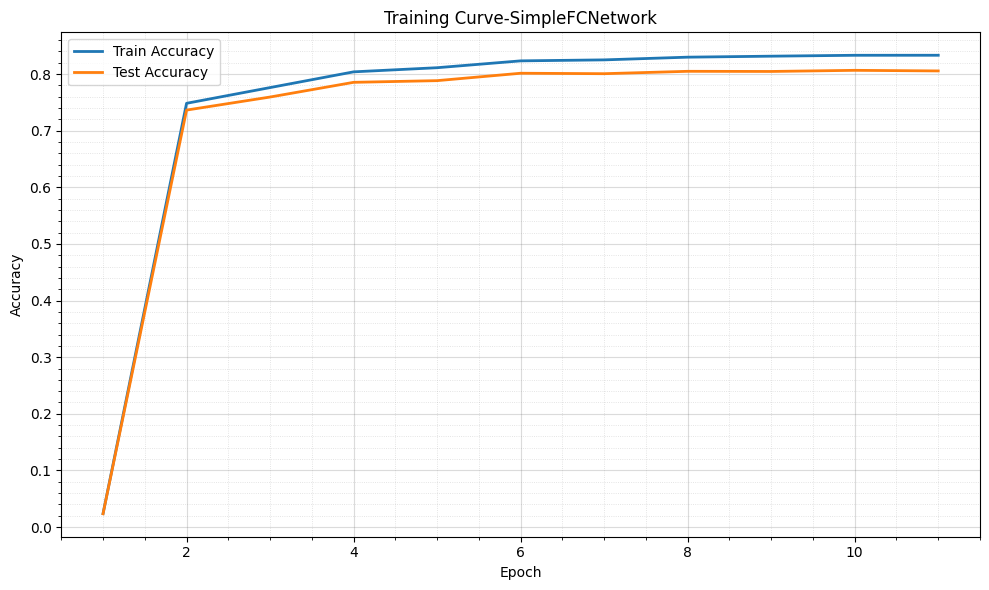

([0.023769946808510637,
  0.7484042553191489,
  0.7761857269503546,
  0.8039671985815603,
  0.8112699468085106,
  0.8233710106382979,
  0.8251108156028368,
  0.82989804964539,
  0.8316489361702127,
  0.8332225177304965,
  0.8332668439716312],
 [0.023404255319148935,
  0.736436170212766,
  0.7594858156028369,
  0.7854609929078015,
  0.7884308510638298,
  0.8015070921985815,
  0.800709219858156,
  0.8049202127659575,
  0.8046542553191489,
  0.8066489361702127,
  0.8055851063829788])

In [14]:
def full_training_loop_and_store_accuracies(ModelType, train_loader, test_loader, num_epochs=10, path='saved_accuracies/', checkpoint_path='saved_model_checkpoints/'):
    """
    Creates an instance of the model, runs a full training loop while recording accuracies, and saves them to disk.
    """

    num_classes = len(label_names)
    if ModelType == SimpleFCNetwork:
        model = ModelType(input_size=28*28,hidden_size=64, num_classes=num_classes).to(device)
    else:
        model = ModelType(num_classes=num_classes).to(device)

    # using checkpoints with the stored models, so that we don't replace better models
    checkpoint_file = os.path.join(checkpoint_path, f'{ModelType.__name__}.pth') 

    initial_best_acc = 0.0 

    if os.path.exists(checkpoint_file): 
        checkpoint = torch.load(checkpoint_file, map_location=device) 
        model.load_state_dict(checkpoint['model_state_dict']) 

        initial_best_acc = evaluate(model, test_loader) 

        # reinitialize so that Part 2 comparison is fair (from scratch) for all models
        if ModelType == SimpleFCNetwork: 
            model = ModelType(input_size=28*28, hidden_size=64, num_classes=num_classes).to(device) 
        else: 
            model = ModelType(num_classes=num_classes).to(device) 
            
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5) 

    model, train_accs, test_accs = train_num_epochs_and_track_accuracies(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=num_epochs,
        initial_best_acc = initial_best_acc,
        scheduler = scheduler,
        with_checkpointing=False
    )
    os.makedirs(path, exist_ok=True)
    np.save(os.path.join(path, f'{ModelType.__name__}_accuracies.npy'),{'train': train_accs, 'test': test_accs})

    final_test_acc = test_accs[-1] 

    if final_test_acc > initial_best_acc: 
        torch.save({'model_state_dict': model.state_dict(),'model_name': ModelType.__name__,'train_accs': train_accs, 'test_accs': test_accs},checkpoint_file,)

    return model, train_accs, test_accs


def load_accuracies_and_create_plots(model_name, accuracies=None, path='saved_accuracies/'):
    """
    Loads previously stored accuracies and creates training curve plots.
    """
    if accuracies is None:
        load_path = os.path.join(path,f'{model_name}_accuracies.npy')
        data = np.load(load_path, allow_pickle=True).item()
        train_accs = data['train']
        test_accs = data['test']
    else:
        train_accs = accuracies['train']
        test_accs= accuracies['test']
    epochs = range(1, len(train_accs) + 1)


    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
    plt.plot(epochs, test_accs,label='Test Accuracy', linewidth=2)
    # to show more detail on this scale 
    plt.minorticks_on()
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training Curve-{model_name}')
    plt.legend()
    # making the grid a bit nicer 
    plt.grid(True,which="major", color="#737373", linestyle="-", linewidth=0.8, alpha=0.25)
    plt.grid(True, which="minor", color="#737373", linestyle=":", linewidth=0.6, alpha=0.25) 
    plt.tight_layout()
    plt.show()
    return train_accs, test_accs

load_accuracies_and_create_plots('SimpleFCNetwork')


In [ ]:
%%time

# training loop for 10 epochs to obtain a clear separation between performances
# we settled on 10 after testing for both longer and shorter periods and finding it an acceptable threshold
all_accuracies = []
# storing the models for visualization & debugging (so we don't have to re-run training everytime)
trained_models = {} 
for ModelType in [SimpleFCNetwork, CNN_SMALL, CNN_BIG, ResNet]:
    print(f"\n{'='*40}\nTraining {ModelType.__name__}\n{'='*40}")
    model, train_accs, test_accs = full_training_loop_and_store_accuracies(ModelType, train_loader, test_loader, num_epochs=10)
    trained_models[ModelType.__name__] = model
    all_accuracies.append({
        'model_name': ModelType.__name__,
        'train': train_accs,
        'test':  test_accs
    })



Training SimpleFCNetwork
evaluating model
Train acc: 0.022218528368794326 | Test acc: 0.02353723404255319
batch 9023/9024 loss: 0.67369830608367925
Epoch: 0 | avg batch loss: 1.1928976775553235
evaluating model
Train acc: 0.741688829787234 | Test acc: 0.7335992907801419
batch 9023/9024 loss: 0.532275080680847264
Epoch: 1 | avg batch loss: 0.8032431042846457
evaluating model
Train acc: 0.7805961879432625 | Test acc: 0.7640514184397164
batch 9023/9024 loss: 0.901990711688995474
Epoch: 2 | avg batch loss: 0.6647522448139358
evaluating model
Train acc: 0.806815159574468 | Test acc: 0.7864804964539007
batch 9023/9024 loss: 0.829789817333221444
Epoch: 3 | avg batch loss: 0.6273665102124413
evaluating model
Train acc: 0.8175975177304965 | Test acc: 0.7929078014184398
batch 9023/9024 loss: 0.420648276805877795
Epoch: 4 | avg batch loss: 0.57972420086995
evaluating model
Train acc: 0.8246897163120568 | Test acc: 0.7974290780141844
batch 9023/9024 loss: 0.397534132003784246
Epoch: 5 | avg batch

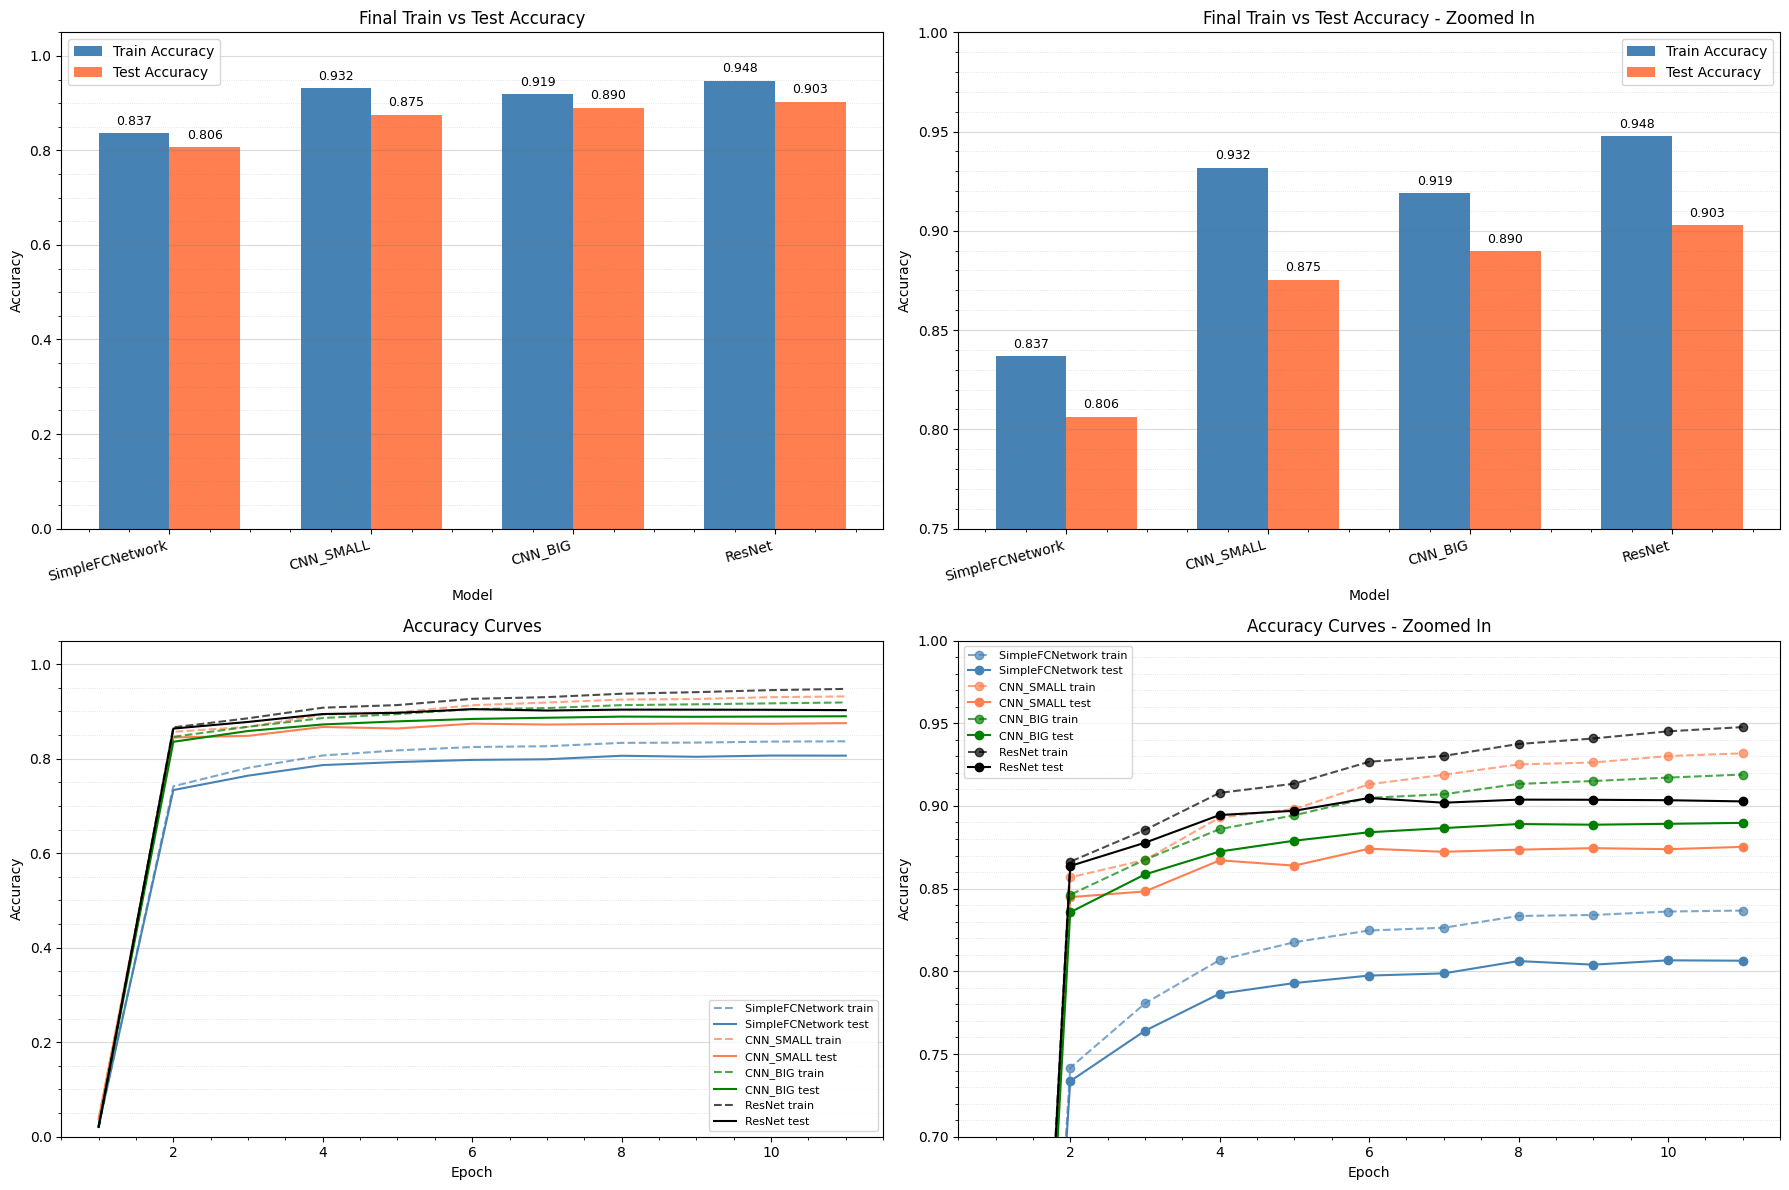

In [18]:
# detaching plotting from the training loop
def comparison_plot(accuracies):
    """
    Creates a bar plot comparing the final train and test accuracies of multiple models.

    Args:
        accuracies: List of dicts, each with keys:
            - 'model_name': str
            - 'train': list of train accuracies per epoch
            - 'test':  list of test  accuracies per epoch
    """
    model_names = [entry['model_name'] for entry in accuracies]
    final_train = [entry['train'][-1] for entry in accuracies]
    final_test = [entry['test'][-1] for entry in accuracies]

    x = np.arange(len(model_names))
    width = 0.35

    fig, axes = plt.subplots(2,2,figsize=(18, 12))

    # first plot to show the accuracies as bars
    ax = axes[0,0]

    bars_train = ax.bar(x-width/2, final_train, width, label='Train Accuracy',color='steelblue')
    bars_test  = ax.bar(x+width/2, final_test, width, label='Test Accuracy', color='coral')

    for bar in list(bars_train) + list(bars_test):
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    ax.set_title('Final Train vs Test Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.minorticks_on()
    ax.grid(True, which='major', axis='y', color='#737373', linestyle='-', linewidth=0.8, alpha=0.25)
    ax.grid(True, which='minor', axis='y', color='#737373', linestyle=':', linewidth=0.6, alpha=0.25) 

    # second plot to show the bar plot differences zoomed in 
    ax = axes[0,1]

    bars_train = ax.bar(x-width/2, final_train, width, label='Train Accuracy', color='steelblue')
    bars_test = ax.bar(x+width/2, final_test, width, label='Test Accuracy', color='coral') 

    for bar in list(bars_train) + list(bars_test): 
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                    xytext=(0,4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9) 
    ax.set_xlabel('Model') 
    ax.set_ylabel('Accuracy') 
    ax.set_title('Final Train vs Test Accuracy - Zoomed In') 
    ax.set_xticks(x) 
    ax.set_xticklabels(model_names, rotation=15, ha='right') 
    ax.set_ylim(0.75, 1.00) 
    ax.legend() 
    ax.minorticks_on() 
    ax.grid(True, which='major', axis='y', color='#737373', linestyle='-', linewidth=0.8, alpha=0.25) 
    ax.grid(True, which='minor', axis='y', color='#737373', linestyle=':', linewidth=0.6, alpha=0.25) 

    # third plot to show accuracy curves per epoch 
    ax = axes[1,0] 

    colors = ['steelblue','coral', 'green', 'black']
    for i, entry in enumerate(accuracies):
        epochs = range(1, len(entry['train']) + 1)
        ax.plot(epochs, entry['train'], linestyle='--', color=colors[i], alpha=0.7, label=f"{entry['model_name']} train")
        ax.plot(epochs, entry['test'], linestyle='-', color=colors[i], label=f"{entry['model_name']} test")
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Curves')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.minorticks_on() 
    ax.grid(True, which='major', axis='y', color='#737373', linestyle='-', linewidth=0.8, alpha=0.25)
    ax.grid(True, which='minor', axis='y', color='#737373', linestyle=':', linewidth=0.6, alpha=0.25) 

    # fourth plot to show differences in accuracy curves zoommed in 
    ax = axes[1,1]

    colors = ['steelblue','coral', 'green', 'black']

    for i, entry in enumerate(accuracies):
        epochs = range(1, len(entry['train']) + 1)
        ax.plot(epochs, entry['train'], linestyle='--',marker='o', color=colors[i], alpha=0.7, label=f"{entry['model_name']} train")
        ax.plot(epochs, entry['test'], linestyle='-',marker='o', color=colors[i], label=f"{entry['model_name']} test")
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Curves - Zoomed In')
    ax.set_ylim(0.70, 1.00)
    ax.legend(fontsize=8)
    ax.minorticks_on() 
    ax.grid(True, which='major', axis='y', color='#737373', linestyle='-', linewidth=0.8, alpha=0.25)
    ax.grid(True, which='minor', axis='y', color='#737373', linestyle=':', linewidth=0.6, alpha=0.25) 

    plt.tight_layout()
    plt.show()

comparison_plot(all_accuracies)

### 🖊️📜 (400 words max)

Discuss here the structure of the implemented neural network architectures and analyse the plots you created in order to compare their performances.  

The **Simple CF Network** model is a simple dense network, consisting of an fully connected input layer (28x28), a hidden layer (64) and an output layer (47). The idea is that the model will read in the 28x28 grayscaled image as a flat array, extract 64 features into the hidden layer and finally output a confidence level to each of the 47 class labels.

The **CNN_SMALL** builds on the first, simple dense network, by prepending it with two convolution layers for more effective **local** feature extraction. Now the role of the dense layers is to combine the extracted features. To improve training and inference speed, it uses pooling steps for dimensionality reduction.

To better fit the training data, the **CNN_BIG** model increases both the number of convolution and dense layers. By this, the model can extarct more features and make more complex combinations.

The shown comparison plots clearly show that the CNN based model marginally outperform the simple FC model, which is due to the more effective localized feature extracttion allowed by the convolution layers. We can observe that the SMALL and BIG CNN-s perform similarly, which likely means that a simple size increase does not result in big performance improvements. On the other hand, by considering residual learning with ResNet, we can see a small but significant improvement in performance.



## Part 3: Hyperparameter Optimisation Study
In this task, you will learn how to perform a hyperparameter optimisation study. Training a neural network involves different parameters, like batch size, learning rate, weight decay etc. Those parameters have to be set before the training and their choice determines if the network converges at all and how well the network performs in the end. 

There are various ways to perform hyperparameter optimisation, but the basic idea is to search the best possible combination of parameters in terms of network performance. For that a network can be trained for a few epochs for each parameter combination and evaluated. The best performing combination should then be chosen and the network can be trained for the total desired amount of epochs with the optimized hyperparameters. Perform the hyperparameter optimisation for the **big CNN** model with 25 trials! You are allowed to take a section of the train set as a validation set for the hyperparameter optimisation!

We will not focus on the theory (grid search, random search, bayesian optimisation) behind it, the scope of this task is that you have performed HPO at least once in your studies and that you know how it practically works.

In [31]:
# Don't forget to do a train/validation/test split
from torch.utils.data import random_split

def objective(trial):
    # --- suggest hyperparameters ---
    lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])

    # --- build loaders with this trial's batch size, seeded train loader ---
    trial_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(69))
    trial_val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # --- model, optimizer, loss ---
    model = CNN_BIG(num_classes=len(label_names)).to(device)
    optimizer = (optim.Adam if optimizer_name == 'Adam' else optim.SGD)(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    # adding a scheduler to better compare with default model
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    loss_fn = nn.CrossEntropyLoss()

    # --- train for a few epochs ---
    train_num_epochs(model, trial_train_loader, optimizer, loss_fn, num_epochs=10, scheduler=scheduler)

    # --- evaluate on validation set ---
    val_acc = evaluate(model, trial_val_loader)

    # --- free memory (important across 25 trials) ---
    del model
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

    return val_acc

In [32]:
from torch.utils.data import random_split, DataLoader, Subset
from torchvision.datasets import EMNIST
from torchvision.transforms import ToTensor

EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=False, transform=ToTensor())
label_names = EMNIST_dataset.classes

# small subset for HPO - no GPU so we keep it manageable - was used for experiments on small subsets before committing 
# hpo_dataset = Subset(EMNIST_dataset, indices=range(7000))

n = len(EMNIST_dataset)
train_size = int(0.70 * n)
val_size   = int(0.15 * n)
test_size  = n - train_size - val_size

# modifying for GPU run
train_dataset, val_dataset, test_dataset = random_split(
    EMNIST_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(69)
)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print("Best trial:")
print(f"  Validation accuracy: {study.best_trial.value:.4f}")
print(f"  Hyperparameters: {study.best_trial.params}")

[I 2026-05-21 21:14:15,677] A new study created in memory with name: no-name-79a8963f-cb71-4311-bd34-5c70a291e7d0


batch 616/617 loss: 3.8474993705749517
Epoch: 0 | avg batch loss: 3.8517152787800546
batch 616/617 loss: 3.8441102504730225
Epoch: 1 | avg batch loss: 3.8399161840373925
batch 616/617 loss: 3.8615424633026123
Epoch: 2 | avg batch loss: 3.8309314301180106
batch 616/617 loss: 3.8242008686065674
Epoch: 3 | avg batch loss: 3.825185129669536
batch 616/617 loss: 3.8141396045684814
Epoch: 4 | avg batch loss: 3.820969730374106
batch 616/617 loss: 3.7980477809906006
Epoch: 5 | avg batch loss: 3.818672011312055
batch 616/617 loss: 3.8197200298309326
Epoch: 6 | avg batch loss: 3.8163885108076
batch 616/617 loss: 3.8233573436737066
Epoch: 7 | avg batch loss: 3.8153224683078415
batch 616/617 loss: 3.8086602687835693
Epoch: 8 | avg batch loss: 3.8138613557892835
batch 616/617 loss: 3.8173975944519043
Epoch: 9 | avg batch loss: 3.813012365777064


[I 2026-05-21 21:14:53,292] Trial 0 finished with value: 0.050118203309692674 and parameters: {'lr': 0.0002086313111136483, 'batch_size': 128, 'weight_decay': 8.281670226640421e-05, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.050118203309692674.


batch 1233/1234 loss: 0.94344836473464975
Epoch: 0 | avg batch loss: 1.1017807540234716
batch 1233/1234 loss: 0.79678899049758916
Epoch: 1 | avg batch loss: 0.7149454259118926
batch 1233/1234 loss: 0.79979586601257324
Epoch: 2 | avg batch loss: 0.5635133464632004
batch 1233/1234 loss: 0.38202512264251716
Epoch: 3 | avg batch loss: 0.5410963183984377
batch 1233/1234 loss: 0.39935377240180974
Epoch: 4 | avg batch loss: 0.4679648533970649
batch 1233/1234 loss: 0.55336499214172367
Epoch: 5 | avg batch loss: 0.4615081450879284
batch 1233/1234 loss: 0.57271045446395874
Epoch: 6 | avg batch loss: 0.41881867940122536
batch 1233/1234 loss: 0.33133044838905334
Epoch: 7 | avg batch loss: 0.40822936494259626
batch 1233/1234 loss: 0.30871930718421936
Epoch: 8 | avg batch loss: 0.3804692172564602
batch 1233/1234 loss: 0.36337447166442876
Epoch: 9 | avg batch loss: 0.37543120937998525


[I 2026-05-21 21:15:54,461] Trial 1 finished with value: 0.8838652482269503 and parameters: {'lr': 0.003112362343006234, 'batch_size': 64, 'weight_decay': 0.002858804339045853, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.8838652482269503.


...

batch 2467/2468 loss: 0.75365871191024785
Epoch: 0 | avg batch loss: 0.9362958755036227
batch 2467/2468 loss: 0.57457184791564947
Epoch: 1 | avg batch loss: 0.5515369783537508
batch 2467/2468 loss: 0.35819858312606815
Epoch: 2 | avg batch loss: 0.43071135098787816
batch 2467/2468 loss: 0.24411790072917938
Epoch: 3 | avg batch loss: 0.3962887182644594
batch 2467/2468 loss: 0.30346280336380005
Epoch: 4 | avg batch loss: 0.3425838671084282
batch 2467/2468 loss: 0.16198477149009705
Epoch: 5 | avg batch loss: 0.32513811428407796
batch 2467/2468 loss: 0.25341305136680603
Epoch: 6 | avg batch loss: 0.29891566737182135
batch 2467/2468 loss: 0.152439549565315256
Epoch: 7 | avg batch loss: 0.28681912737320414
batch 2467/2468 loss: 0.068908475339412695
Epoch: 8 | avg batch loss: 0.2740896492992713
batch 2467/2468 loss: 0.126898318529129035
Epoch: 9 | avg batch loss: 0.27035031437940255


[I 2026-05-21 21:48:50,710] Trial 23 finished with value: 0.8958037825059102 and parameters: {'lr': 0.0008056610647780887, 'batch_size': 32, 'weight_decay': 2.773962429460625e-05, 'optimizer': 'Adam'}. Best is trial 23 with value: 0.8958037825059102.


batch 2467/2468 loss: 0.61857873201370243
Epoch: 0 | avg batch loss: 0.9926103629183923
batch 2467/2468 loss: 0.42810994386672974
Epoch: 1 | avg batch loss: 0.5324514333514958
batch 2467/2468 loss: 0.35441565513610845
Epoch: 2 | avg batch loss: 0.4320428888698379
batch 2467/2468 loss: 0.37780544161796575
Epoch: 3 | avg batch loss: 0.406414047028489
batch 2467/2468 loss: 0.50486081838607793
Epoch: 4 | avg batch loss: 0.3662403816088575
batch 2467/2468 loss: 0.91658788919448858
Epoch: 5 | avg batch loss: 0.35269969724106637
batch 2467/2468 loss: 0.15079933404922485
Epoch: 6 | avg batch loss: 0.33172321734977117
batch 2467/2468 loss: 0.22118654847145086
Epoch: 7 | avg batch loss: 0.32430096800217173
batch 2467/2468 loss: 0.11641179025173187
Epoch: 8 | avg batch loss: 0.31392030844636976
batch 2467/2468 loss: 0.272345423698425385
Epoch: 9 | avg batch loss: 0.3104295589201865


[I 2026-05-21 21:50:38,028] Trial 24 finished with value: 0.8904255319148936 and parameters: {'lr': 0.00031808250340527316, 'batch_size': 32, 'weight_decay': 6.919494488360783e-05, 'optimizer': 'Adam'}. Best is trial 23 with value: 0.8958037825059102.


Best trial:
  Validation accuracy: 0.8958
  Hyperparameters: {'lr': 0.0008056610647780887, 'batch_size': 32, 'weight_decay': 2.773962429460625e-05, 'optimizer': 'Adam'}


Now that you have found the best parameters for the network to train, use them to train the network for 10 epochs and analyse it in your report. Compare the network accuracy you achieve now with the accuracy you previously achieved!

evaluating model
Train acc: 0.021200607902735563 | Test acc: 0.019030732860520094
batch 2467/2468 loss: 0.39718389511108455
Epoch: 0 | avg batch loss: 0.9175755847939796
evaluating model
Train acc: 0.8384245187436676 | Test acc: 0.8333924349881797
batch 2467/2468 loss: 0.56476223468780522
Epoch: 1 | avg batch loss: 0.535128172188152
evaluating model
Train acc: 0.8677938196555218 | Test acc: 0.8585697399527187
batch 2467/2468 loss: 0.37420621514320374
Epoch: 2 | avg batch loss: 0.42468155738467434
evaluating model
Train acc: 0.8847517730496454 | Test acc: 0.8764775413711584
batch 2467/2468 loss: 0.22499690949916843
Epoch: 3 | avg batch loss: 0.3929395571387278
evaluating model
Train acc: 0.8926925025329281 | Test acc: 0.8819148936170212
batch 2467/2468 loss: 0.154223144054412846
Epoch: 4 | avg batch loss: 0.3438522916927185
evaluating model
Train acc: 0.902532928064843 | Test acc: 0.8856382978723404
batch 2467/2468 loss: 0.30734747648239136
Epoch: 5 | avg batch loss: 0.3244186594789452


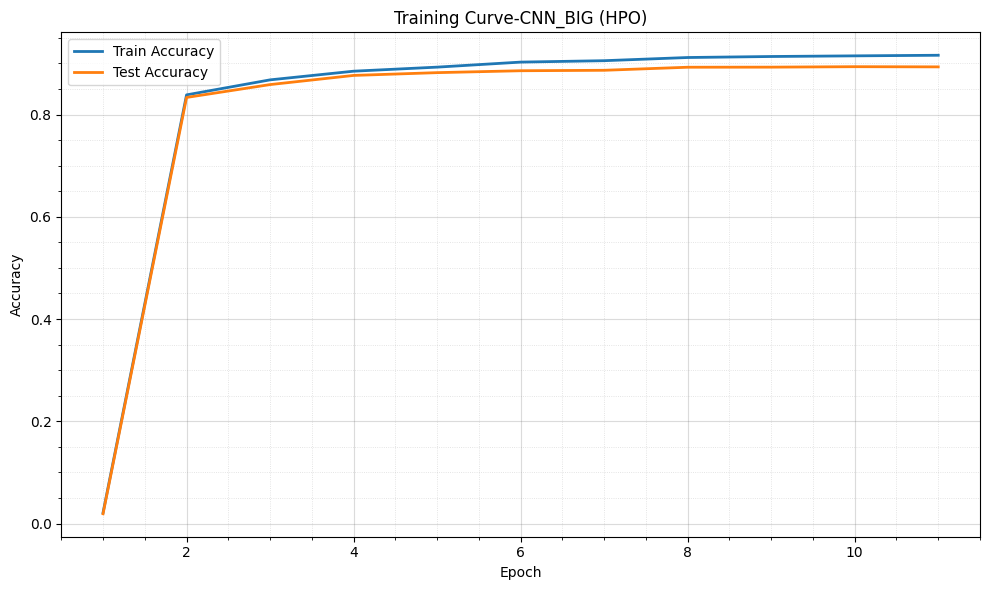

([0.021200607902735563,
  0.8384245187436676,
  0.8677938196555218,
  0.8847517730496454,
  0.8926925025329281,
  0.902532928064843,
  0.9052938196555218,
  0.9115121580547112,
  0.9134878419452888,
  0.9147543059777102,
  0.915919452887538],
 [0.019030732860520094,
  0.8333924349881797,
  0.8585697399527187,
  0.8764775413711584,
  0.8819148936170212,
  0.8856382978723404,
  0.8865248226950354,
  0.8924940898345154,
  0.8926713947990543,
  0.8935579196217495,
  0.8932033096926714])

In [33]:
# the best trials
best = study.best_trial.params

# full dataset loaders this time
full_train_loader = DataLoader(train_dataset, batch_size=best['batch_size'], shuffle=True, generator=torch.Generator().manual_seed(69))
full_test_loader  = DataLoader(test_dataset,  batch_size=best['batch_size'], shuffle=False)

# rebuild model fresh
best_model = CNN_BIG(num_classes=len(label_names)).to(device)

optimizer = (optim.Adam if best['optimizer'] == 'Adam' else optim.SGD)(
    best_model.parameters(), lr=best['lr'], weight_decay=best['weight_decay']
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
loss_fn = nn.CrossEntropyLoss()

best_model, train_accs, test_accs = train_num_epochs_and_track_accuracies(
    model=best_model,
    train_loader=full_train_loader,
    test_loader=full_test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=10,
    with_checkpointing=False,
    scheduler=scheduler
)

torch.save({'model_state_dict': best_model.state_dict(), 'model_name': 'CNN_BIG_HPO', 'best_params': best, 'train_accs': train_accs,'test_accs': test_accs}, 'saved_model_checkpoints/CNN_BIG_HPO.pth')

load_accuracies_and_create_plots('CNN_BIG (HPO)', accuracies={'train': train_accs, 'test': test_accs})

### 🖊️📜 (250 words max)

The HPO study was implemented using Optuna with 25 trials, each training CNN_BIG for 10 epochs on the full EMNIST balanced training split. The objective function suggests hyperparameters per trial, trains the model, and returns validation accuracy, which Optuna maximizes.

The search space consisted of four hyperparameters: learning rate (log-uniform between 1e-4 and 1e-2), batch size (categorical: 32, 64, 128), weight decay (log-uniform between 1e-5 and 1e-2), and optimizer (Adam or SGD). Learning rate and weight decay were sampled on a log scale. The best trial found lr=0.0008057, batch_size=32, weight_decay=2.77e-05, with Adam as optimizer, achieving 0.8958 validation accuracy.

After the HPO search, we trained a fresh CNN_BIG model trained for 10 epochs using the best hyperparameters. The final model reached 0.9159 train and 0.8932 test accuracy. This is quite close to CNN_BIG trained in Part 2 with default parameters (0.9190 train, 0.8898 test). We see a small improvement from HPO on the test accuracy and a similar train-test gap. Part of the difference could also be explained due to the separate train/validation/test split used, which can also explain why HPO did not improve the already high train accuracy.

A key pitfall of HPO is overfitting to the validation set. Running many trials means one is implicitly optimizing for that specific split, so selected hyperparameters may not generalize perfectly to the final test set. Some SGD trials also converged poorly showing that HPO results depend strongly on chosen search space. 

## Part 4: Explainable AI

In this task, you will learn about Explainable AI. This is a branch of AI that seeks to develop methods that help us explain why AI models behave as they do. For this assignment, we will focus on probing, although there are many other XAI methods. Probing is a technique that seeks to determine whether a particular concept is "stored" at a particular layer in a model. For example, in a model as  any of the ones in this assingment, we may want to determine if this model stores information on whether this character is a number or a letter, when presented with a character. While the final task does not differentiate between numbers and letters, it is possible that the model still makes this distinction somewhere througout its layers. In order to discover this, we can follow this process:

- Feed the model EMNIST images and let it perform inference, but record the activations of the model at each of its layers for each image shown. Do this to create train and test activation sets and save them.
- Train a very simple model, which we call a probe, with the input being the activations of the original model at a particular layer, and the output being whether this character is a number or a letter. The model should be very simple (e.g linear regression).
- Test this probe on the test set of activations, and observe how well the probe is at predicting whether a character is a number or a letter by only looking at the activations at a particular layer.
- Train another probe at the same layer, but in this case, instead of making it predict whether a character is a number or a letter, make it predict a random meaningless task with the same structure as the standard task (so it should also be binary and have similar label quantity proportions. For example, here there are two reasonable control tasks: first one is give each character a number/letter label randomly, so all "a"s become a number, "b"s a letter, "7"s a letter, etc. Second one is give each image a number/letter label randomly regardless of its character). Then, test this control probe (the test set should also use control labels generated in the same random way)
- If the standard probe performs better than the control probe, this indicates that the activations at this layer contain some information that encodes whether the character was a letter or a number.
- We do the same thing for all layers to observe at what layers this information is most clearly encoded.

Your task for this part of the assignment is to perform a small probing study with the **big CNN model**. You need to set up the code infrastructure to carry out probing experiments, and report the results along with a reflection on what these results may mean. **Remember to also create a control task for each of these tasks**; this is very important, and for each task you should think carefully about the way the control task labels should be created. To ensure a reasonable computation time, you should generate the activations of **at most** 2560 images per split to run your study. These are the specific tasks you need to implement:

### Task 1

Make a probe that predicts if the image contains a letter or a number.

### Task 2

Make a probe that predicts the amount of closed segments in the image. For example, "9" has one closed circle, "8" has two, "a" has one, and "T" has zero. Since this may depend on the font (e.g "g" can have 1 or 2 depending on the font), determining the number of segments for every single image in the EMNIST dataset is challenging. To simplify the task, you can assume every image associated with each of these characters has the same number of closed segments and use the following list:

- 1 closed segment: 0, 4, 6, 9, a, b, d, e, o, p, q, A, D, O, P, Q, R
- 2 closed segments: 8, g, B
- 0 closed segments: everything else

Take into account that EMNIST balance merges some characters that are considered potentially indistinguishable in written form, such as "o" and "O".

### Task 3

Make a probe that performs the same task as the model it is built on top of (predict the specific character class present in the image).

### Task 4

Come up with a new probing task and implement it. Explain why this task is interesting.

Generating test activations:  15%|█▌        | 80/529 [00:00<00:01, 408.28it/s]



Task: number_vs_letter
block1      : 0.804
block2      : 0.833
block3      : 0.867
fc1_post_relu: 0.907
fc2_post_relu: 0.925
fc3_logits  : 0.909

Task: closed_segments
block1      : 0.787
block2      : 0.905
block3      : 0.950
fc1_post_relu: 0.968
fc2_post_relu: 0.975
fc3_logits  : 0.968

Task: character_class
block1      : 0.650
block2      : 0.775
block3      : 0.838
fc1_post_relu: 0.865
fc2_post_relu: 0.875
fc3_logits  : 0.877

Task: vertical_symmetry
block1      : 0.786
block2      : 0.834
block3      : 0.871
fc1_post_relu: 0.938
fc2_post_relu: 0.958
fc3_logits  : 0.930

Task: number_vs_letter_control
block1      : 0.668
block2      : 0.658
block3      : 0.658
fc1_post_relu: 0.768
fc2_post_relu: 0.781
fc3_logits  : 0.785

Task: closed_segments_control
block1      : 0.511
block2      : 0.500
block3      : 0.482
fc1_post_relu: 0.566
fc2_post_relu: 0.591
fc3_logits  : 0.623

Task: character_class_control
block1      : 0.020
block2      : 0.020
block3      : 0.023
fc1_post_relu: 0.01

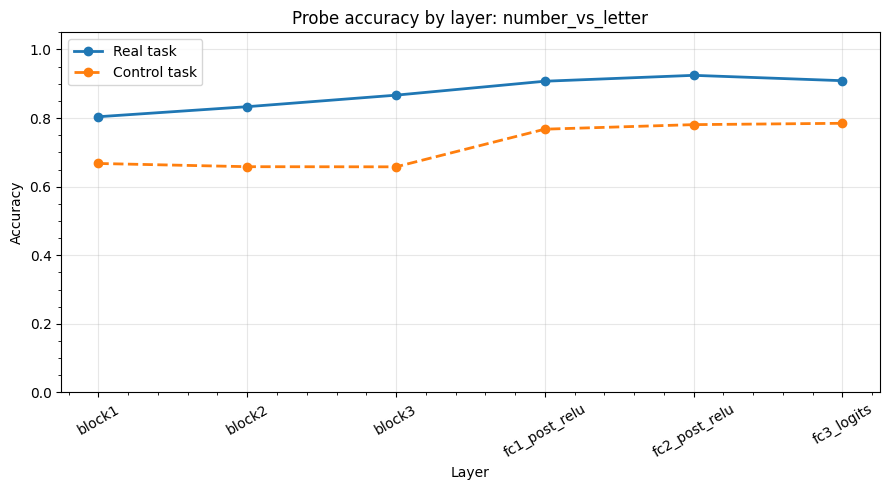

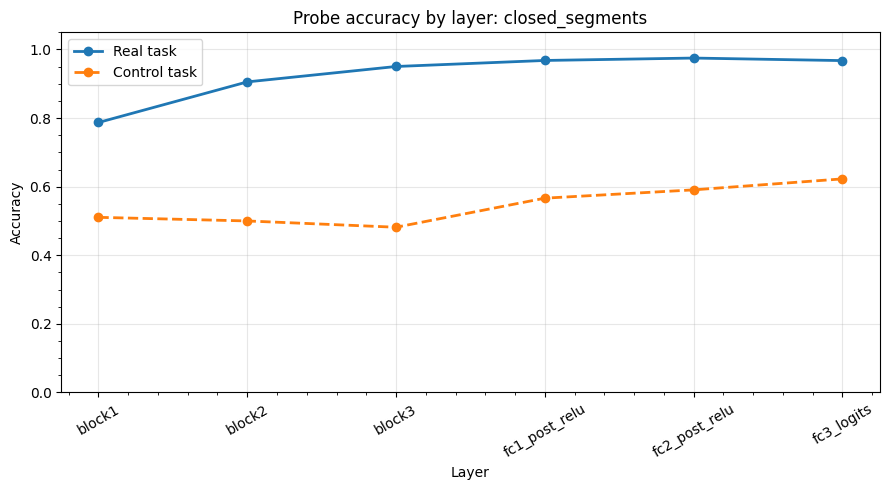

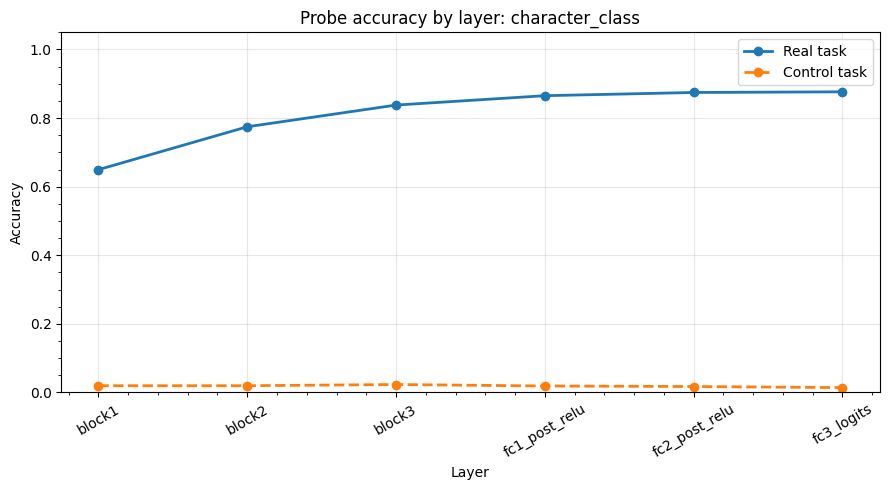

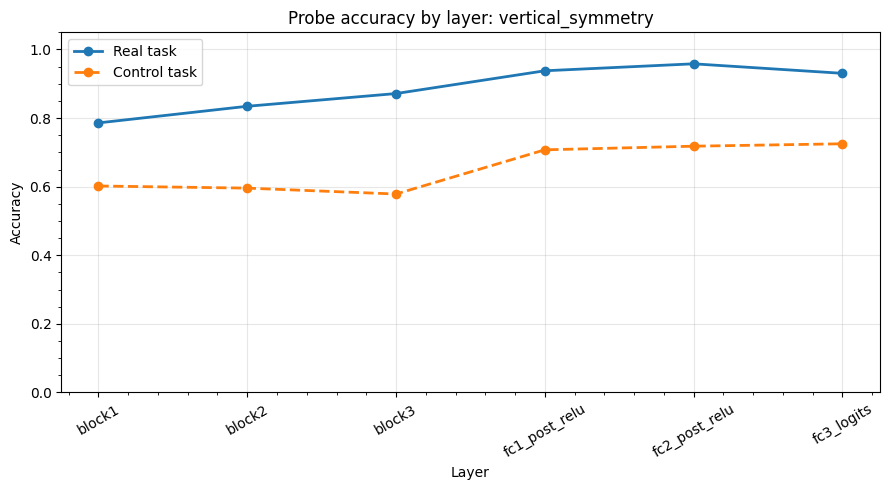

In [34]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# new import to get accuracy 
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from random import seed
from typing import Any, Callable
from pathlib import Path

# Create ActivationLoader class, which lets us store activations from models, save them, and load them from files.
class ActivationLoader:
    """Loads a model and extracts activations from its layers"""

    def __init__(self, model, device, save_dir="saved_activations"):
        self.model = model.to(device) 
        self.device = device 
        self.save_dir = Path(save_dir) 
        self.save_dir.mkdir(exist_ok=True) 

        # following the CNN_BIG architecture 
        # we store after each convolutional block and fully connected stage
        self.layer_names = [
            "block1", "block2", "block3", "fc1_post_relu", "fc2_post_relu", "fc3_logits" 
        ]

        self.activations = {} 

    def generate_activations(
        self,
        dataloader: torch.utils.data.DataLoader,
        split: str,
        save_to_disk: bool,
        amount_to_generate: int,
    ) -> None:
        """
        Extract activations from all layers by running forward passes through the dataloader.

        Args:
            dataloader: DataLoader with images and labels for activation extraction
            split: Either "train" or "test" for naming saved files
            save_to_disk: Whether to save activations to disk
            amount_to_generate: Maximum number of samples to extract activations for
        """
        # inform torch we're evaluating 
        self.model.eval() 

        collected = { name: [] for name in self.layer_names} 
        labels = [] 
        seen = 0 

        with torch.no_grad():
            for images, batch_labels in tqdm(dataloader, desc=f"Generating {split} activations"): 
                remaining = amount_to_generate - seen 
                if remaining <= 0: 
                    break 

                images = images[:remaining].to(self.device) 
                batch_labels = batch_labels[:remaining] 

                # reusing the forward path of CNN BIG forward() with saved activations
                if images.dim() == 3: 
                    images = images.unsqueeze(1) 

                # activations moved to cpu because the probes use numpy arrays 
                x = self.model.pool(F.relu(self.model.bn1(self.model.conv1(images))))
                collected["block1"].append(x.flatten(start_dim=1).cpu())

                x = self.model.pool(F.relu(self.model.bn2(self.model.conv2(x))))
                collected["block2"].append(x.flatten(start_dim=1).cpu())

                x = self.model.pool(F.relu(self.model.bn3(self.model.conv3(x))))
                collected["block3"].append(x.flatten(start_dim=1).cpu()) 

                x = x.view(x.size(0), -1) 

                x = F.relu(self.model.fc1(x)) 
                collected["fc1_post_relu"].append(x.cpu()) 

                x = self.model.dropout(x) 
                x = F.relu(self.model.fc2(x)) 
                collected["fc2_post_relu"].append(x.cpu()) 

                x = self.model.fc3(x) 
                collected["fc3_logits"].append(x.cpu()) 

                labels.append(batch_labels.cpu()) 
                seen += len(batch_labels) 
            
        # Store all activations for the split
        self.activations[split] = {
            "layers": {
                layer_name: torch.cat(layer_activations, dim=0)
                for layer_name, layer_activations in collected.items()
            },
            "labels": torch.cat(labels, dim=0) 
        }

        if save_to_disk: 
            torch.save(self.activations[split], self.save_dir / f"{split}_activations.pt") 
        
            
class Probe:
    """
    Probe for classification tasks on neural network activations. Should use a linear 
    model (e.g linear regression)
    """

    def __init__(self, d_in, d_out, classes):
        self.d_in = d_in 
        self.d_out = d_out 
        self.classes = classes 
        
        # scale activation features to avoid large-magnitudes skewing
        self.scaler = StandardScaler() 
        # we're using logistic regression as a linear classifier for categorical targets
        self.model = LogisticRegression(max_iter=1000, solver="lbfgs") 

    def fit(self, acts, labels): 
        acts = acts.numpy() 
        labels = labels.numpy() if isinstance(labels, torch.Tensor) else labels 

        # fit scaler on training activations
        acts = self.scaler.fit_transform(acts) 
        # train logistic regression probe
        self.model.fit(acts, labels) 

    def predict(self, acts): 
        acts = acts.numpy() 
        acts = self.scaler.transform(acts) 
        return self.model.predict(acts) 
    
    # computing accuracy of the probe as the score
    def score(self, acts, labels):
        labels = labels.numpy() if isinstance(labels, torch.Tensor) else labels
        predictions = self.predict(acts) 
        return accuracy_score(labels, predictions) 


def create_probe_from_data(acts, labels):
    """
    Create and train a Probe.

    Args:
        acts: Activation tensor of shape (num_samples, activation_dim)
        labels: Label tensor of shape (num_samples,) for classification targets

    Returns:
        Trained Probe instance ready for inference
    """
    
    classes = sorted(labels.unique().tolist()) 
    d_in = acts.shape[1] 
    d_out = len(classes) 

    # initialize linear probe and train it
    probe = Probe(d_in=d_in, d_out=d_out, classes=classes) 
    probe.fit(acts, labels) 

    return probe 

def generate_all_labels_of_probing_tasks(original_labels):
    """
    Implement a function that takes in the original labels of the dataset,
    and based on these creates the labels required for every probing task.
    Make sure to include the control tasks too.
    """

    # convert labels from tensors to numpy
    original_labels_np = original_labels.numpy() 
    id_to_char = {idx:char for idx , char in enumerate(label_names)} 

    # Task 2 - characters with one clsoed segment
    one_closed_segment = set([
        "0", "4", "6", "9", "a", "b", "d", "e", "o", "p", "q", "A", "D", "O", "P", "Q", "R" 
    ])

    # Task 2 - characters with two closed segments 
    two_closed_segments = set(["8", "g", "B"])

    # Task 4 - self-defined probe, on characters having vertical symmetry
    vertical_symmetry_charset = set(["0", "8", "A", "H", "I", "M", "O", "T", "W", "X", "V", "Y", "o", "v", "w", "x"])

    num_vs_let = [] 
    closed_segments = [] 
    symmetry = [] 

    # iterate on the EMNIST labels and encode them for the probes 
    for label in original_labels_np: 
        char = str(id_to_char[int(label)]) 

        if char.isdigit(): 
            num_vs_let.append(0) 
        else: 
            num_vs_let.append(1)

        if char in one_closed_segment: 
            closed_segments.append(1)
        elif char in two_closed_segments:
            closed_segments.append(2) 
        else: 
            closed_segments.append(0) 


        if char in vertical_symmetry_charset:
            symmetry.append(1) 
        else: 
            symmetry.append(0) 

    # store probing task labels
    task_labels = {
        "number_vs_letter": torch.tensor(num_vs_let), 
        "closed_segments": torch.tensor(closed_segments),
        "character_class": original_labels.clone(), 
        "vertical_symmetry": torch.tensor(symmetry), 
    }  

    # generate randomized control labels
    control_labels = {} 

    for task_name, labels in task_labels.items():
        shuffled_labels = labels.clone() 
        shuffled_indices = torch.randperm(len(shuffled_labels)) 
        control_labels[f"{task_name}_control"] = shuffled_labels[shuffled_indices] 
        

    return { 
        **task_labels, 
        **control_labels 
    }


def plot_metrics() -> None:
    """
    Plot the accuracy (or precision, recall, f1 or whichever metric you see fit) 
    of the probe predictions over the layers (one line for the probe trained on 
    the standard task. Another line for the probe trained on the control task)
    """

    for task in probing_results: 
        if task.endswith("_control"):
            continue 

        control_task = f"{task}_control" 

        plt.figure(figsize=(9,5)) 

        plt.plot(
            layer_names, 
            probing_results[task], 
            marker="o",
            linewidth=2, 
            label="Real task"
        )

        plt.plot(
            layer_names,
            probing_results[control_task],
            marker="o", 
            linewidth=2, 
            linestyle="--",
            label="Control task"
        )

        plt.title(f"Probe accuracy by layer: {task}")
        plt.xlabel("Layer") 
        plt.ylabel("Accuracy") 
        plt.ylim(0, 1.05) 
        plt.xticks(rotation=30) 
        plt.grid(True, alpha=0.3) 
        plt.minorticks_on() 
        plt.tight_layout()
        plt.legend() 
        plt.show() 

# probe HPO trained CNN_BIG (part 3)
activation_loader = ActivationLoader(best_model, device) 

# extract activations for 2560 train/test images 
activation_loader.generate_activations(
    dataloader=full_train_loader,
    split="train", 
    save_to_disk=True,
    amount_to_generate=2560, 
)

activation_loader.generate_activations(
    dataloader=full_test_loader, 
    split="test", 
    save_to_disk=True, 
    amount_to_generate=min(2560, len(full_test_loader.dataset))
)

train_activations = activation_loader.activations["train"] 
test_activations = activation_loader.activations["test"]

train_probe_labels = generate_all_labels_of_probing_tasks(train_activations["labels"]) 
test_probe_labels = generate_all_labels_of_probing_tasks(test_activations["labels"]) 

layer_names = activation_loader.layer_names 
probing_results = {} 

# loop over real and control tasks
for task_name in train_probe_labels: 
    probing_results[task_name] = [] 

    print(f"\nTask: {task_name}") 
    
    # train and evaluate one probe at each activation layer 
    for layer_name in layer_names: 
        train_layer_acts = train_activations["layers"][layer_name] 
        test_layer_acts = test_activations["layers"][layer_name] 

        probe = create_probe_from_data(acts=train_layer_acts, labels=train_probe_labels[task_name]) 

        accuracy= probe.score(acts=test_layer_acts, labels=test_probe_labels[task_name]) 

        probing_results[task_name].append(accuracy) 

        print(f"{layer_name:12s}: {accuracy:.3f}") 

plot_metrics()


### 🖊️📜 (200 words max)
Answer the following:

- Why is a control task necessary? Couldn't we just do the standard task?
- Why do we use very simple models as probes? Wouldn't a neural network with many layers be better?
- If a probing experiment gives positive results, does this necessarily mean that the model actually uses this information during inference? Why or why not?
- Why would we ask you to do a probing task that is the same as the original task (character classification)? Does this probing task tell us anything new compared to just observing the original model's performance?

- We use a control task as a way to test whether our probe performance can be trusted. The probe model is kept the same but the labels are randomized. This disrupts the connection between the original image and the target, and so we are able to infer whether the CNN_BIG activations actually capture the intended concept, or if our probe has a design issue or shows operational artifacts.

- We use simple models as probes because our goal is to test whether a concept is retrievable from the activation layers. A NN can learn a complex transformation which would make it hard to discern if the information was present in CNN_BIG or generated by the probe. A linear classifier uses the activation vector directly and extracts linearly accessible information from them.

- Positive probe results do not prove that the model uses the concept during inference. The information is encoded in vectors, which may result from visual feature extraction or due to contingent correlations with the original task.

- The character class probe is useful because it checks when the character classification info becomes accessible. It shows us how class information evolves across layers, and the control version fails because randomized class labels have no actual relationship to the real characters when probed.

### 🖊️📜 (50 words max)

What probe did you make for task 4? What was the idea behind it?

The probe we chose was on vertical symmetry. Its idea is to test whether characters that are vertically symmetric are retrievable. We chose it because symmetry is a human recognizable visual property that is not an explicit EMINST label, but may still be encoded by CNN_BIG because it helps distinguish handwritten characters.

### 🖊️📜 (300 words max)

Make a small report on your results. What do you observe looking at the graphs? Can you explain why your curves may look like this? What do they tell you about whether (and if so, at what layers) the model stores any of the concepts we were trying to probe for?

=== just a short overview ===
The probing results show that real tasks outperform control tasks. This shows us that CNN_BIG actually contains information that is meaningful about the concepts we are probign. For all probes, except from character class which shows a continuous increase we have a rise until fc2_post_relu, after which we see a slight drop in the final logits. The reason we see is that concepts which are different than the actual training objective (everything excepting character_class) are most recoverable in the hidden representations which exemplify a high complexity, before compressing to the final output. 

Control probes are also significantly lower, especially character_class_control which stays slightly above chance for most probes. 

=== Need to add more content and talk about the task in general ===